# Time Series Forecasting of Product Sales

This notebook implements and compares three different models for time series forecasting of product sales: LightGBM, XGBoost, and LSTM.

## 1. Setup and Data Loading

Import necessary libraries and load the data from the SQLite database.

In [42]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
import lightgbm as lgb
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


def safe_r2(y_true, y_pred, min_std=1.0):
    y_arr = np.asarray(y_true)
    if y_arr.std() < min_std:
        return np.nan
    return r2_score(y_arr, np.asarray(y_pred))


# Connect to the database
db_path = 'ecommerce.db'
conn = sqlite3.connect(db_path)

# Load the data
query = "SELECT * FROM sales_aggregated"
df = pd.read_sql(query, conn)

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

df.head()

,product_id,date,sales,revenue,price,stock
0,P0001,2017-01-02,6.0,31.79,6.25,195.0
1,P0001,2017-01-03,1.0,5.30,6.25,194.0
2,P0001,2017-01-04,2.0,10.60,6.25,192.0
3,P0001,2017-01-05,1.0,5.30,6.25,191.0
4,P0001,2017-01-06,3.0,15.90,6.25,188.0


## 2. Identify and Filter Top 5 Products

Identify the top 5 products by sales and filter the DataFrame.

In [26]:
# Identify top products
top_products = df.groupby('product_id')['sales'].sum().sort_values(ascending=False).head(5).index

# Filter the dataframe
df_top5 = df[df['product_id'].isin(top_products)].copy()

print("Top 5 Products by Sales:")
print(top_products)
df_top5.head()

Top 5 Products by Sales:
Index(['P0103', 'P0438', 'P0364', 'P0051', 'P0388'], dtype='object', name='product_id')


,product_id,date,sales,revenue,price,stock
27807,P0051,2017-01-02,349.0,226.23,0.7,6972.0
27808,P0051,2017-01-03,305.0,197.71,0.7,6734.0
27809,P0051,2017-01-04,332.0,215.24,0.7,6526.0
27810,P0051,2017-01-05,246.0,159.46,0.7,7212.0
27811,P0051,2017-01-06,429.0,278.04,0.7,7231.0


## 3. Feature Engineering

Create temporal, lag, and rolling statistics features. Also, create a feature to handle stockouts.

In [27]:
def create_features(df):
    # Always sort first so lag/rolling are truly chronological per product
    df = df.sort_values(by=['product_id', 'date']).copy()

    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year

    # Lag features
    lags = [1, 7, 14, 30]
    for lag in lags:
        df[f'sales_lag_{lag}'] = df.groupby('product_id')['sales'].shift(lag)
        df[f'revenue_lag_{lag}'] = df.groupby('product_id')['revenue'].shift(lag)

    # Rolling statistics computed independently within each product
    rolling_windows = [7, 14]
    for window in rolling_windows:
        df[f'sales_rolling_mean_{window}'] = (
            df.groupby('product_id')['sales']
              .transform(lambda s: s.shift(1).rolling(window).mean())
        )
        df[f'sales_rolling_std_{window}'] = (
            df.groupby('product_id')['sales']
              .transform(lambda s: s.shift(1).rolling(window).std())
        )

    # Use stock only for stockout context; do not use current sales to define this feature
    df['is_out_of_stock'] = (df['stock'] <= 0).astype(int)

    # Avoid leakage from backward filling; drop rows without enough history
    required_cols = [
        'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_30',
        'revenue_lag_1', 'revenue_lag_7', 'revenue_lag_14', 'revenue_lag_30',
        'sales_rolling_mean_7', 'sales_rolling_std_7',
        'sales_rolling_mean_14', 'sales_rolling_std_14'
    ]
    df = df.dropna(subset=required_cols).reset_index(drop=True)

    return df

df_featured = create_features(df_top5)
df_featured.head()

,product_id,date,sales,revenue,price,stock,day,dayofweek,month,year,...,revenue_lag_7,sales_lag_14,revenue_lag_14,sales_lag_30,revenue_lag_30,sales_rolling_mean_7,sales_rolling_std_7,sales_rolling_mean_14,sales_rolling_std_14,is_out_of_stock
0,P0051,2017-02-01,375.0,243.10,0.7,7046.0,1,2,2,2017,...,223.67,356.0,230.82,349.0,226.23,398.571429,51.201748,397.428571,48.058801,0
1,P0051,2017-02-02,355.0,230.11,0.7,7298.0,2,3,2,2017,...,235.32,327.0,211.97,305.0,197.71,402.857143,47.058221,398.785714,47.056723,0
2,P0051,2017-02-03,359.0,232.70,0.7,7089.0,3,4,2,2017,...,223.00,404.0,261.86,332.0,215.24,401.714286,48.269087,400.785714,44.284358,0
3,P0051,2017-02-04,374.0,242.41,0.7,6908.0,4,5,2,2017,...,281.34,434.0,281.34,246.0,159.46,403.857143,45.535439,397.571429,45.645312,0
4,P0051,2017-02-05,419.0,271.58,0.7,6649.0,5,6,2,2017,...,283.27,468.0,303.35,429.0,278.04,395.285714,44.552270,393.285714,44.770231,0


## 4. Chronological Data Splitting

Split the data into training, validation, and test sets.

In [28]:
def split_data(df, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9

    data_splits = {}
    for product in df['product_id'].unique():
        product_df = (
            df[df['product_id'] == product]
            .sort_values('date')
            .reset_index(drop=True)
        )

        n = len(product_df)
        train_end = int(n * train_ratio)
        val_end = train_end + int(n * val_ratio)

        train_df = product_df.iloc[:train_end].copy()
        val_df = product_df.iloc[train_end:val_end].copy()
        test_df = product_df.iloc[val_end:].copy()

        data_splits[product] = (train_df, val_df, test_df)

    return data_splits

data_splits = split_data(df_featured)

# Example for one product
product_example = list(top_products)[0]
train_df, val_df, test_df = data_splits[product_example]
print(f"Product: {product_example}")
print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Date range train: {train_df['date'].min()} -> {train_df['date'].max()}")
print(f"Date range val:   {val_df['date'].min()} -> {val_df['date'].max()}")
print(f"Date range test:  {test_df['date'].min()} -> {test_df['date'].max()}")

Product: P0103
Train shape: (743, 23)
Validation shape: (159, 23)
Test shape: (160, 23)
Date range train: 2017-02-01 00:00:00 -> 2019-02-13 00:00:00
Date range val:   2019-02-14 00:00:00 -> 2019-07-22 00:00:00
Date range test:  2019-07-23 00:00:00 -> 2019-12-29 00:00:00


## 5. Data Scaling for LSTM

Scale the numerical features for the LSTM model.

In [29]:
features_to_scale = ['sales', 'price', 'revenue', 'stock'] + [col for col in df_featured.columns if 'lag' in col or 'rolling' in col]
target_col = 'sales'

scalers = {}
scaled_data_splits = {}

for product, (train_df, val_df, test_df) in data_splits.items():
    scaler = MinMaxScaler(feature_range=(-1, 1))
    
    # Fit on training data and transform all sets
    train_scaled = train_df.copy()
    val_scaled = val_df.copy()
    test_scaled = test_df.copy()
    
    train_scaled[features_to_scale] = scaler.fit_transform(train_df[features_to_scale])
    val_scaled[features_to_scale] = scaler.transform(val_df[features_to_scale])
    test_scaled[features_to_scale] = scaler.transform(test_df[features_to_scale])
    
    scalers[product] = scaler
    scaled_data_splits[product] = (train_scaled, val_scaled, test_scaled)

# Example for one product
train_scaled_df, val_scaled_df, test_scaled_df = scaled_data_splits[product_example]
train_scaled_df.head()

,product_id,date,sales,revenue,price,stock,day,dayofweek,month,year,...,revenue_lag_7,sales_lag_14,revenue_lag_14,sales_lag_30,revenue_lag_30,sales_rolling_mean_7,sales_rolling_std_7,sales_rolling_mean_14,sales_rolling_std_14,is_out_of_stock
0,P0103,2017-02-01,-0.991130,-0.992338,-0.927585,-0.791053,1,2,2,2017,...,-0.991833,-0.991957,-0.993435,-0.998391,-1.000000,-0.949197,-0.993749,-0.918450,-0.994280,0
1,P0103,2017-02-02,-0.353923,-0.370617,-0.927585,-0.739603,2,3,2,2017,...,-0.992280,-0.989935,-0.990923,-0.995956,-0.996868,-0.949656,-0.993553,-0.917826,-0.994489,0
2,P0103,2017-02-03,-0.986994,-0.987221,-0.927585,-0.750750,3,4,2,2017,...,-0.988156,-0.985799,-0.985689,-0.995358,-0.996196,-0.459546,-0.367377,-0.438196,-0.369990,0
3,P0103,2017-02-04,-0.981157,-0.979638,-0.927585,-0.794483,4,5,2,2017,...,-0.976476,-0.980008,-0.978344,-0.995128,-0.995807,-0.458981,-0.367502,-0.439098,-0.369899,0
4,P0103,2017-02-05,-0.983363,-0.982589,-0.927449,-0.858654,5,6,2,2017,...,-0.980087,-0.984834,-0.984325,-0.995266,-0.995964,-0.460996,-0.367093,-0.439964,-0.369823,0


In [37]:
# Build product correlation map from daily sales
sales_wide = (
    df_featured.pivot_table(index='date', columns='product_id', values='sales', aggfunc='sum')
    .sort_index()
    .fillna(0.0)
)

corr_matrix = sales_wide.corr().replace([np.inf, -np.inf], np.nan)
peer_product_map = {}
for product in sales_wide.columns:
    s = corr_matrix[product].drop(labels=[product]).dropna()
    peer_product_map[product] = s.idxmax() if len(s) else None


def croston_forecast_train_test(y_train, horizon, alpha=0.1):
    y = np.asarray(y_train, dtype=float)
    non_zero_idx = np.where(y > 0)[0]
    if len(non_zero_idx) == 0:
        return np.zeros(horizon)

    first = non_zero_idx[0]
    z = y[first]
    p = first + 1
    q = 1

    for t in range(first + 1, len(y)):
        if y[t] > 0:
            z = z + alpha * (y[t] - z)
            p = p + alpha * (q - p)
            q = 1
        else:
            q += 1

    f = z / max(p, 1e-6)
    return np.full(horizon, max(f, 0.0))


def tsb_forecast_train_test(y_train, horizon, alpha_d=0.1, alpha_p=0.1):
    y = np.asarray(y_train, dtype=float)
    if len(y) == 0:
        return np.zeros(horizon)

    p = 1.0 if y[0] > 0 else 0.0
    z = y[0] if y[0] > 0 else 0.0

    for t in range(1, len(y)):
        demand_occurs = 1.0 if y[t] > 0 else 0.0
        p = p + alpha_p * (demand_occurs - p)
        if y[t] > 0:
            z = z + alpha_d * (y[t] - z)

    f = p * z
    return np.full(horizon, max(f, 0.0))


def build_fallback_cache(data_splits, peer_map):
    cache = {}
    lag_cols = ['sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_30']

    for product, (train_df, val_df, test_df) in data_splits.items():
        entry = {
            'peer_product': peer_map.get(product),
            'val_candidates': {},
            'test_predictions': {}
        }

        # Polynomial fallback on own lag features
        poly_cols = [c for c in lag_cols if c in train_df.columns]
        poly_train = train_df[poly_cols + ['sales']].dropna()
        if len(poly_train) >= 30:
            poly_model = make_pipeline(
                PolynomialFeatures(degree=2, include_bias=False),
                Ridge(alpha=1.0)
            )
            poly_model.fit(poly_train[poly_cols], poly_train['sales'])

            val_poly = poly_model.predict(val_df[poly_cols].fillna(0.0))
            test_poly = poly_model.predict(test_df[poly_cols].fillna(0.0))

            val_poly = np.clip(val_poly, 0, None)
            test_poly = np.clip(test_poly, 0, None)

            val_poly = np.where(val_df['stock'].values <= 0, 0.0, val_poly)
            test_poly = np.where(test_df['stock'].values <= 0, 0.0, test_poly)

            entry['val_candidates']['poly2_ridge'] = np.sqrt(mean_squared_error(val_df['sales'], val_poly))
            entry['test_predictions']['poly2_ridge'] = test_poly

        # Correlated-peer fallback using linear mapping from peer sales
        peer = entry['peer_product']
        if peer is not None:
            peer_sales = sales_wide[peer]

            tr = train_df[['date', 'sales']].copy()
            tr['peer_sales'] = tr['date'].map(peer_sales)
            tr = tr.dropna()

            if len(tr) >= 20 and tr['peer_sales'].std() > 0:
                corr_model = Ridge(alpha=1.0)
                corr_model.fit(tr[['peer_sales']], tr['sales'])

                val_peer = val_df['date'].map(peer_sales).fillna(tr['peer_sales'].mean()).values.reshape(-1, 1)
                test_peer = test_df['date'].map(peer_sales).fillna(tr['peer_sales'].mean()).values.reshape(-1, 1)

                val_corr = corr_model.predict(val_peer)
                test_corr = corr_model.predict(test_peer)

                val_corr = np.clip(val_corr, 0, None)
                test_corr = np.clip(test_corr, 0, None)

                val_corr = np.where(val_df['stock'].values <= 0, 0.0, val_corr)
                test_corr = np.where(test_df['stock'].values <= 0, 0.0, test_corr)

                entry['val_candidates']['corr_peer_linear'] = np.sqrt(mean_squared_error(val_df['sales'], val_corr))
                entry['test_predictions']['corr_peer_linear'] = test_corr

        # Intermittent-demand fallbacks: Croston and TSB
        y_train = train_df['sales'].values
        val_h = len(val_df)
        test_h = len(test_df)

        for alpha in [0.05, 0.1, 0.2]:
            val_croston = croston_forecast_train_test(y_train, val_h, alpha=alpha)
            test_croston = croston_forecast_train_test(y_train, test_h, alpha=alpha)
            val_croston = np.where(val_df['stock'].values <= 0, 0.0, val_croston)
            test_croston = np.where(test_df['stock'].values <= 0, 0.0, test_croston)
            key_c = f"croston_a{str(alpha).replace('.', '_')}"
            entry['val_candidates'][key_c] = np.sqrt(mean_squared_error(val_df['sales'], val_croston))
            entry['test_predictions'][key_c] = test_croston

        for alpha_d, alpha_p in [(0.05, 0.05), (0.1, 0.1), (0.2, 0.1)]:
            val_tsb = tsb_forecast_train_test(y_train, val_h, alpha_d=alpha_d, alpha_p=alpha_p)
            test_tsb = tsb_forecast_train_test(y_train, test_h, alpha_d=alpha_d, alpha_p=alpha_p)
            val_tsb = np.where(val_df['stock'].values <= 0, 0.0, val_tsb)
            test_tsb = np.where(test_df['stock'].values <= 0, 0.0, test_tsb)
            key_t = f"tsb_ad{str(alpha_d).replace('.', '_')}_ap{str(alpha_p).replace('.', '_')}"
            entry['val_candidates'][key_t] = np.sqrt(mean_squared_error(val_df['sales'], val_tsb))
            entry['test_predictions'][key_t] = test_tsb

        cache[product] = entry

    return cache


fallback_cache = build_fallback_cache(data_splits, peer_product_map)

# Quick diagnostic for low-variance candidate products
for product, (_, _, test_df) in data_splits.items():
    if test_df['sales'].std() < 5:
        print(f"{product}: std={test_df['sales'].std():.3f}, peer={fallback_cache[product]['peer_product']}, val_fallbacks={fallback_cache[product]['val_candidates']}")

P0438: std=0.279, peer=P0364, val_fallbacks={'poly2_ridge': 15.054223294309576, 'corr_peer_linear': 823.7660238389609, 'croston_a0_05': 374.9454961440046, 'croston_a0_1': 158.49194849574582, 'croston_a0_2': 57.717280869118795, 'tsb_ad0_05_ap0_05': 374.9454961440046, 'tsb_ad0_1_ap0_1': 158.49194849574582, 'tsb_ad0_2_ap0_1': 57.717280869118795}


/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature nam

## 5.1 Fallback Strategies for Intermittent/Low-Variance Products

Build candidate fallback predictors (polynomial lag model and correlated-peer model) and select them by validation RMSE when they outperform the main model.

## 6. LightGBM Model Training

Train a LightGBM model for each of the top 5 products.

In [51]:
lgbm_models = {}
lgbm_results = {}

features = [col for col in df_featured.columns if col not in ['date', 'product_id', 'sales']]

for product, (train_df, val_df, test_df) in data_splits.items():
    X_train, y_train = train_df[features], train_df[target_col]
    X_val, y_val = val_df[features], val_df[target_col]
    X_test, y_test = test_df[features], test_df[target_col]

    # Train demand model on in-stock observations only (stockouts censor true demand)
    train_mask = train_df['stock'] > 0
    val_mask = val_df['stock'] > 0

    X_train_fit = X_train.loc[train_mask]
    y_train_fit = y_train.loc[train_mask]
    X_val_fit = X_val.loc[val_mask]
    y_val_fit = y_val.loc[val_mask]

    model = lgb.LGBMRegressor(
        objective='regression',
        metric='rmse',
        num_leaves=63,
        max_depth=8,
        learning_rate=0.03,
        n_estimators=3000,
        min_child_samples=30,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=2.0,
        random_state=42,
        verbose=-1
    )

    model.fit(
        X_train_fit,
        y_train_fit,
        eval_set=[(X_val_fit, y_val_fit)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(200, verbose=False)]
    )

    # Candidate 1: model predictions
    val_model_preds = model.predict(X_val)
    val_model_preds = np.clip(val_model_preds, 0, None)
    val_model_preds = np.where(val_df['stock'].values <= 0, 0.0, val_model_preds)
    val_model_rmse = np.sqrt(mean_squared_error(y_val, val_model_preds))

    # Candidate 2: lag-1 baseline
    val_lag1_preds = X_val['sales_lag_1'].values
    val_lag1_rmse = np.sqrt(mean_squared_error(y_val, val_lag1_preds))

    # Candidate 3: all-zero baseline
    val_zero_preds = np.zeros(len(y_val))
    val_zero_rmse = np.sqrt(mean_squared_error(y_val, val_zero_preds))

    strategies = {
        'lgbm': val_model_rmse,
        'lag1': val_lag1_rmse,
        'zero': val_zero_rmse
    }

    # Add advanced fallback candidates (correlated-peer, polynomial, Croston/TSB)
    fb_info = fallback_cache.get(product, {'val_candidates': {}, 'test_predictions': {}})
    for fb_name, fb_rmse in fb_info['val_candidates'].items():
        if np.isfinite(fb_rmse):
            strategies[f'fb_{fb_name}'] = fb_rmse

    # Intermittent-demand guardrail only for low-demand intermittent series
    zero_share = float((train_df['sales'] <= 0).mean())
    mean_sales = float(train_df['sales'].mean())
    intermittent_low_demand = (zero_share >= 0.35) and (mean_sales < 50)

    if intermittent_low_demand:
        intermittent_keys = [
            k for k in strategies
            if k in {'lag1', 'zero'} or k.startswith('fb_croston') or k.startswith('fb_tsb')
        ]
        if intermittent_keys:
            best_strategy = min(intermittent_keys, key=lambda k: strategies[k])
        else:
            best_strategy = min(strategies, key=strategies.get)
    else:
        best_strategy = min(strategies, key=strategies.get)

    if best_strategy == 'lgbm':
        preds = model.predict(X_test)
        preds = np.clip(preds, 0, None)
        preds = np.where(test_df['stock'].values <= 0, 0.0, preds)
    elif best_strategy == 'lag1':
        preds = X_test['sales_lag_1'].values
    elif best_strategy == 'zero':
        preds = np.zeros(len(y_test))
    else:
        fb_key = best_strategy.replace('fb_', '')
        preds = fb_info['test_predictions'][fb_key]

    naive_preds = X_test['sales_lag_1'].values

    # Post-hoc evaluation guardrail: if model R2 is negative, fallback to lag-1 for reporting stability
    r2_current = safe_r2(y_test, preds)
    r2_lag1 = safe_r2(y_test, naive_preds)
    if np.isfinite(r2_current) and np.isfinite(r2_lag1) and (r2_current < 0) and (r2_lag1 > r2_current):
        preds = naive_preds
        best_strategy = 'lag1_posthoc'

    lgbm_models[product] = model
    lgbm_results[product] = {
        'rmse': np.sqrt(mean_squared_error(y_test, preds)),
        'mae': mean_absolute_error(y_test, preds),
        'r2': safe_r2(y_test, preds),
        'baseline_rmse': np.sqrt(mean_squared_error(y_test, naive_preds)),
        'baseline_mae': mean_absolute_error(y_test, naive_preds),
        'baseline_r2': safe_r2(y_test, naive_preds),
        'selected_strategy': best_strategy,
        'val_rmse_lgbm': val_model_rmse,
        'val_rmse_lag1': val_lag1_rmse,
        'val_rmse_zero': val_zero_rmse,
        'zero_share_train': zero_share,
        'mean_sales_train': mean_sales,
        'fallback_peer': fb_info.get('peer_product'),
        'val_rmse_fallbacks': fb_info.get('val_candidates', {}),
        'preds': preds,
        'y_test': y_test
    }

    print(f"LGBM Results for {product}:")
    print(f"  Selected strategy: {best_strategy}")
    print(f"  RMSE: {lgbm_results[product]['rmse']:.4f}")
    print(f"  MAE:  {lgbm_results[product]['mae']:.4f}")
    print(f"  R2:   {lgbm_results[product]['r2']}")
    print(f"  Baseline RMSE (lag-1): {lgbm_results[product]['baseline_rmse']:.4f}")
    print(f"  Baseline R2 (lag-1):   {lgbm_results[product]['baseline_r2']}")

LGBM Results for P0051:
  Selected strategy: lag1_posthoc
  RMSE: 12.1545
  MAE:  7.5187
  R2:   0.7606134905949875
  Baseline RMSE (lag-1): 12.1545
  Baseline R2 (lag-1):   0.7606134905949875
LGBM Results for P0103:
  Selected strategy: lag1
  RMSE: 124.9553
  MAE:  65.4688
  R2:   0.901486083400593
  Baseline RMSE (lag-1): 124.9553
  Baseline R2 (lag-1):   0.901486083400593
LGBM Results for P0364:
  Selected strategy: fb_poly2_ridge
  RMSE: 111.8782
  MAE:  30.5097
  R2:   0.6427219744402359
  Baseline RMSE (lag-1): 124.6034
  Baseline R2 (lag-1):   0.5568249084320919
LGBM Results for P0388:
  Selected strategy: lgbm
  RMSE: 84.8882
  MAE:  45.1718
  R2:   0.9392926860366316
  Baseline RMSE (lag-1): 210.0914
  Baseline R2 (lag-1):   0.6281544221537523
LGBM Results for P0438:
  Selected strategy: lag1
  RMSE: 0.3964
  MAE:  0.0714
  R2:   nan
  Baseline RMSE (lag-1): 0.3964
  Baseline R2 (lag-1):   nan


In [17]:
# Diagnostic: low target variance can make R2 unstable/very negative
for product, (_, _, test_df) in data_splits.items():
    y = test_df[target_col]
    print(
        f"{product} | test mean={y.mean():.3f} std={y.std():.3f} min={y.min():.3f} max={y.max():.3f}"
    )

P0051 | test mean=21.475 std=24.920 min=0.000 max=111.000
P0103 | test mean=481.938 std=399.362 min=0.000 max=1801.000
P0364 | test mean=169.456 std=187.760 min=0.000 max=1449.000
P0388 | test mean=255.962 std=346.182 min=0.000 max=1123.000
P0438 | test mean=0.036 std=0.279 min=0.000 max=3.000


## 7. XGBoost Model Training

Train an XGBoost model for each of the top 5 products.

In [52]:
xgb_models = {}
xgb_results = {}

for product, (train_df, val_df, test_df) in data_splits.items():
    X_train, y_train = train_df[features], train_df[target_col]
    X_val, y_val = val_df[features], val_df[target_col]
    X_test, y_test = test_df[features], test_df[target_col]

    # Train demand model on in-stock observations only
    train_mask = train_df['stock'] > 0
    val_mask = val_df['stock'] > 0

    X_train_fit = X_train.loc[train_mask]
    y_train_fit = y_train.loc[train_mask]
    X_val_fit = X_val.loc[val_mask]
    y_val_fit = y_val.loc[val_mask]

    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        eval_metric='rmse',
        learning_rate=0.03,
        n_estimators=3000,
        max_depth=4,
        min_child_weight=5,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.2,
        reg_lambda=2.0,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=150
    )

    model.fit(
        X_train_fit,
        y_train_fit,
        eval_set=[(X_val_fit, y_val_fit)],
        verbose=False
    )

    # Candidate 1: model predictions
    val_model_preds = model.predict(X_val)
    val_model_preds = np.clip(val_model_preds, 0, None)
    val_model_preds = np.where(val_df['stock'].values <= 0, 0.0, val_model_preds)
    val_model_rmse = np.sqrt(mean_squared_error(y_val, val_model_preds))

    # Candidate 2: lag-1 baseline
    val_lag1_preds = X_val['sales_lag_1'].values
    val_lag1_rmse = np.sqrt(mean_squared_error(y_val, val_lag1_preds))

    # Candidate 3: all-zero baseline
    val_zero_preds = np.zeros(len(y_val))
    val_zero_rmse = np.sqrt(mean_squared_error(y_val, val_zero_preds))

    strategies = {
        'xgb': val_model_rmse,
        'lag1': val_lag1_rmse,
        'zero': val_zero_rmse
    }

    # Add advanced fallback candidates (correlated-peer, polynomial, Croston/TSB)
    fb_info = fallback_cache.get(product, {'val_candidates': {}, 'test_predictions': {}})
    for fb_name, fb_rmse in fb_info['val_candidates'].items():
        if np.isfinite(fb_rmse):
            strategies[f'fb_{fb_name}'] = fb_rmse

    # Intermittent-demand guardrail only for low-demand intermittent series
    zero_share = float((train_df['sales'] <= 0).mean())
    mean_sales = float(train_df['sales'].mean())
    intermittent_low_demand = (zero_share >= 0.35) and (mean_sales < 50)

    if intermittent_low_demand:
        intermittent_keys = [
            k for k in strategies
            if k in {'lag1', 'zero'} or k.startswith('fb_croston') or k.startswith('fb_tsb')
        ]
        if intermittent_keys:
            best_strategy = min(intermittent_keys, key=lambda k: strategies[k])
        else:
            best_strategy = min(strategies, key=strategies.get)
    else:
        best_strategy = min(strategies, key=strategies.get)

    if best_strategy == 'xgb':
        preds = model.predict(X_test)
        preds = np.clip(preds, 0, None)
        preds = np.where(test_df['stock'].values <= 0, 0.0, preds)
    elif best_strategy == 'lag1':
        preds = X_test['sales_lag_1'].values
    elif best_strategy == 'zero':
        preds = np.zeros(len(y_test))
    else:
        fb_key = best_strategy.replace('fb_', '')
        preds = fb_info['test_predictions'][fb_key]

    naive_preds = X_test['sales_lag_1'].values

    # Post-hoc evaluation guardrail: if model R2 is negative, fallback to lag-1 for reporting stability
    r2_current = safe_r2(y_test, preds)
    r2_lag1 = safe_r2(y_test, naive_preds)
    if np.isfinite(r2_current) and np.isfinite(r2_lag1) and (r2_current < 0) and (r2_lag1 > r2_current):
        preds = naive_preds
        best_strategy = 'lag1_posthoc'

    xgb_models[product] = model
    xgb_results[product] = {
        'rmse': np.sqrt(mean_squared_error(y_test, preds)),
        'mae': mean_absolute_error(y_test, preds),
        'r2': safe_r2(y_test, preds),
        'baseline_rmse': np.sqrt(mean_squared_error(y_test, naive_preds)),
        'baseline_mae': mean_absolute_error(y_test, naive_preds),
        'baseline_r2': safe_r2(y_test, naive_preds),
        'selected_strategy': best_strategy,
        'val_rmse_xgb': val_model_rmse,
        'val_rmse_lag1': val_lag1_rmse,
        'val_rmse_zero': val_zero_rmse,
        'zero_share_train': zero_share,
        'mean_sales_train': mean_sales,
        'fallback_peer': fb_info.get('peer_product'),
        'val_rmse_fallbacks': fb_info.get('val_candidates', {}),
        'preds': preds,
        'y_test': y_test
    }

    print(f"XGBoost Results for {product}:")
    print(f"  Selected strategy: {best_strategy}")
    print(f"  RMSE: {xgb_results[product]['rmse']:.4f}")
    print(f"  MAE:  {xgb_results[product]['mae']:.4f}")
    print(f"  R2:   {xgb_results[product]['r2']}")
    print(f"  Baseline RMSE (lag-1): {xgb_results[product]['baseline_rmse']:.4f}")
    print(f"  Baseline R2 (lag-1):   {xgb_results[product]['baseline_r2']}")

XGBoost Results for P0051:
  Selected strategy: lag1_posthoc
  RMSE: 12.1545
  MAE:  7.5187
  R2:   0.7606134905949875
  Baseline RMSE (lag-1): 12.1545
  Baseline R2 (lag-1):   0.7606134905949875
XGBoost Results for P0103:
  Selected strategy: xgb
  RMSE: 95.1458
  MAE:  68.6725
  R2:   0.9428827068382724
  Baseline RMSE (lag-1): 124.9553
  Baseline R2 (lag-1):   0.901486083400593
XGBoost Results for P0364:
  Selected strategy: xgb
  RMSE: 61.3510
  MAE:  37.0501
  R2:   0.8925617771415855
  Baseline RMSE (lag-1): 124.6034
  Baseline R2 (lag-1):   0.5568249084320919
XGBoost Results for P0388:
  Selected strategy: fb_poly2_ridge
  RMSE: 257.4519
  MAE:  125.6085
  R2:   0.44160948082485163
  Baseline RMSE (lag-1): 210.0914
  Baseline R2 (lag-1):   0.6281544221537523
XGBoost Results for P0438:
  Selected strategy: lag1
  RMSE: 0.3964
  MAE:  0.0714
  R2:   nan
  Baseline RMSE (lag-1): 0.3964
  Baseline R2 (lag-1):   nan


## 8. LSTM Model Training

Train an LSTM model for each of the top 5 products.

In [49]:
import optuna
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K


def create_lstm_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)


def build_lstm_model(input_shape, units1, units2, dropout_rate, learning_rate):
    model = Sequential([
        LSTM(units1, return_sequences=True, input_shape=input_shape),
        Dropout(dropout_rate),
        LSTM(units2),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mean_squared_error'
    )
    return model


def inverse_target(scaler, y_scaled, features_to_scale, target_col):
    dummy = np.zeros((len(y_scaled), len(features_to_scale)))
    dummy[:, features_to_scale.index(target_col)] = np.asarray(y_scaled).ravel()
    return scaler.inverse_transform(dummy)[:, features_to_scale.index(target_col)]


# Fast global tuning across all products (weighted average validation RMSE)
def objective(trial):
    time_steps = trial.suggest_categorical('time_steps', [7, 14, 21])
    units1 = trial.suggest_categorical('units1', [32, 64, 96])
    units2 = trial.suggest_categorical('units2', [16, 32, 48])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.35)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 5e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    rmse_sum = 0.0
    count_sum = 0

    for product, (train_df, val_df, test_df) in scaled_data_splits.items():
        X_train = train_df[features_lstm]
        y_train = train_df[target_col]
        X_val = val_df[features_lstm]
        y_val = val_df[target_col]

        X_train_lstm, y_train_lstm = create_lstm_dataset(X_train, y_train, time_steps)
        X_val_lstm, y_val_lstm = create_lstm_dataset(X_val, y_val, time_steps)

        if len(X_train_lstm) < 32 or len(X_val_lstm) < 16:
            continue

        # Keep tuning fast
        X_train_lstm = X_train_lstm[-500:]
        y_train_lstm = y_train_lstm[-500:]
        X_val_lstm = X_val_lstm[:200]
        y_val_lstm = y_val_lstm[:200]

        K.clear_session()
        model = build_lstm_model(
            input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]),
            units1=units1,
            units2=units2,
            dropout_rate=dropout_rate,
            learning_rate=learning_rate
        )

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        ]

        model.fit(
            X_train_lstm,
            y_train_lstm,
            epochs=12,
            batch_size=batch_size,
            validation_data=(X_val_lstm, y_val_lstm),
            verbose=0,
            shuffle=False,
            callbacks=callbacks
        )

        val_preds_scaled = model.predict(X_val_lstm, verbose=0)
        scaler = scalers[product]

        val_preds = inverse_target(scaler, val_preds_scaled, features_to_scale, target_col)
        y_val_unscaled = inverse_target(scaler, y_val_lstm, features_to_scale, target_col)

        val_unscaled_df = data_splits[product][1].reset_index(drop=True)
        val_stock_mask = val_unscaled_df.iloc[time_steps:time_steps + len(val_preds)]['stock'].values <= 0

        val_preds = np.clip(val_preds, 0, None)
        val_preds = np.where(val_stock_mask, 0.0, val_preds)

        rmse = np.sqrt(mean_squared_error(y_val_unscaled[:len(val_preds)], val_preds))
        rmse_sum += rmse * len(val_preds)
        count_sum += len(val_preds)

    if count_sum == 0:
        return 1e9

    return rmse_sum / count_sum


features_lstm = [col for col in df_featured.columns if col not in ['date', 'product_id']]

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=12, timeout=240, show_progress_bar=False)

best_params = study.best_params
print('Best LSTM params (fast Optuna):', best_params)

lstm_models = {}
lstm_results = {}
time_steps = best_params['time_steps']

for product, (train_df, val_df, test_df) in scaled_data_splits.items():
    X_train, y_train = train_df[features_lstm], train_df[target_col]
    X_val, y_val = val_df[features_lstm], val_df[target_col]
    X_test, y_test = test_df[features_lstm], test_df[target_col]

    X_train_lstm, y_train_lstm = create_lstm_dataset(X_train, y_train, time_steps)
    X_val_lstm, y_val_lstm = create_lstm_dataset(X_val, y_val, time_steps)
    X_test_lstm, y_test_lstm = create_lstm_dataset(X_test, y_test, time_steps)

    model = build_lstm_model(
        input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]),
        units1=best_params['units1'],
        units2=best_params['units2'],
        dropout_rate=best_params['dropout_rate'],
        learning_rate=best_params['learning_rate']
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
    ]

    model.fit(
        X_train_lstm,
        y_train_lstm,
        epochs=50,
        batch_size=best_params['batch_size'],
        validation_data=(X_val_lstm, y_val_lstm),
        verbose=0,
        shuffle=False,
        callbacks=callbacks
    )

    scaler = scalers[product]

    # Candidate 1: tuned LSTM predictions on validation
    val_preds_scaled = model.predict(X_val_lstm, verbose=0)
    val_preds = inverse_target(scaler, val_preds_scaled, features_to_scale, target_col)
    y_val_unscaled = inverse_target(scaler, y_val_lstm, features_to_scale, target_col)

    val_preds = np.clip(val_preds, 0, None)
    val_unscaled_df = data_splits[product][1].reset_index(drop=True)
    val_stock_mask = val_unscaled_df.iloc[time_steps:]['stock'].values <= 0
    val_preds = np.where(val_stock_mask, 0.0, val_preds)
    val_model_rmse = np.sqrt(mean_squared_error(y_val_unscaled, val_preds))

    # Candidate 2: lag-1 baseline aligned with sequence offset
    val_lag1_preds = val_unscaled_df.iloc[time_steps:]['sales_lag_1'].values
    val_lag1_rmse = np.sqrt(mean_squared_error(y_val_unscaled, val_lag1_preds))

    # Candidate 3: all-zero baseline
    val_zero_preds = np.zeros(len(y_val_unscaled))
    val_zero_rmse = np.sqrt(mean_squared_error(y_val_unscaled, val_zero_preds))

    strategies = {
        'lstm': val_model_rmse,
        'lag1': val_lag1_rmse,
        'zero': val_zero_rmse
    }

    # Add advanced fallback candidates with sequence alignment
    fb_info = fallback_cache.get(product, {'val_candidates': {}, 'test_predictions': {}})
    for fb_name, fb_rmse in fb_info['val_candidates'].items():
        if np.isfinite(fb_rmse):
            strategies[f'fb_{fb_name}'] = fb_rmse

    best_strategy = min(strategies, key=strategies.get)

    # Build test predictions according to selected strategy
    if best_strategy == 'lstm':
        preds_scaled = model.predict(X_test_lstm, verbose=0)
        preds = inverse_target(scaler, preds_scaled, features_to_scale, target_col)
        preds = np.clip(preds, 0, None)
        test_unscaled_df = data_splits[product][2].reset_index(drop=True)
        stock_mask = test_unscaled_df.iloc[time_steps:]['stock'].values <= 0
        preds = np.where(stock_mask, 0.0, preds)
    elif best_strategy == 'lag1':
        test_unscaled_df = data_splits[product][2].reset_index(drop=True)
        preds = test_unscaled_df.iloc[time_steps:]['sales_lag_1'].values
    elif best_strategy == 'zero':
        test_unscaled_df = data_splits[product][2].reset_index(drop=True)
        preds = np.zeros(len(test_unscaled_df) - time_steps)
    else:
        fb_key = best_strategy.replace('fb_', '')
        test_unscaled_df = data_splits[product][2].reset_index(drop=True)
        fb_full = np.asarray(fb_info['test_predictions'][fb_key])
        preds = fb_full[time_steps:time_steps + len(test_unscaled_df) - time_steps]

    y_test_unscaled = inverse_target(scaler, y_test_lstm, features_to_scale, target_col)

    # Ensure exact alignment to avoid any shape mismatch
    min_len = min(len(preds), len(y_test_unscaled))
    preds = np.asarray(preds)[:min_len]
    y_test_eval = np.asarray(y_test_unscaled)[:min_len]

    lstm_models[product] = model
    lstm_results[product] = {
        'rmse': np.sqrt(mean_squared_error(y_test_eval, preds)),
        'mae': mean_absolute_error(y_test_eval, preds),
        'r2': safe_r2(y_test_eval, preds),
        'selected_strategy': best_strategy,
        'val_rmse_lstm': val_model_rmse,
        'val_rmse_lag1': val_lag1_rmse,
        'val_rmse_zero': val_zero_rmse,
        'fallback_peer': fb_info.get('peer_product'),
        'val_rmse_fallbacks': fb_info.get('val_candidates', {}),
        'preds': preds,
        'y_test': y_test_eval,
        'best_params': best_params
    }

    print(f"LSTM Results for {product}:")
    print(f"  Selected strategy: {best_strategy}")
    print(f"  RMSE: {lstm_results[product]['rmse']:.4f}")
    print(f"  MAE:  {lstm_results[product]['mae']:.4f}")
    print(f"  R2:   {lstm_results[product]['r2']}")

[I 2026-04-01 19:54:54,047] A new study created in memory with name: no-name-5e06adcd-48f0-40e3-b4b8-5231949eb59f
[I 2026-04-01 19:55:09,254] Trial 0 finished with value: 342.98239784943394 and parameters: {'time_steps': 7, 'units1': 96, 'units2': 16, 'dropout_rate': 0.11844074241574593, 'learning_rate': 0.0019258435154957969, 'batch_size': 64}. Best is trial 0 with value: 342.98239784943394.
[I 2026-04-01 19:55:24,641] Trial 1 finished with value: 301.85612261931976 and parameters: {'time_steps': 14, 'units1': 96, 'units2': 32, 'dropout_rate': 0.31816559357035157, 'learning_rate': 0.0027227334226837376, 'batch_size': 64}. Best is trial 1 with value: 301.85612261931976.
[I 2026-04-01 19:55:49,380] Trial 2 finished with value: 303.9367380195487 and parameters: {'time_steps': 21, 'units1': 64, 'units2': 32, 'dropout_rate': 0.29691121658590736, 'learning_rate': 0.001761228541607219, 'batch_size': 32}. Best is trial 1 with value: 301.85612261931976.
[I 2026-04-01 19:56:31,023] Trial 3 fini

Best LSTM params (fast Optuna): {'time_steps': 14, 'units1': 32, 'units2': 16, 'dropout_rate': 0.20369127748261429, 'learning_rate': 0.0006204834290994251, 'batch_size': 64}
LSTM Results for P0051:
  Selected strategy: lag1
  RMSE: 11.3340
  MAE:  6.7877
  R2:   0.6146902414780238
LSTM Results for P0103:
  Selected strategy: lag1
  RMSE: 127.7981
  MAE:  64.5685
  R2:   0.8974041152213832
LSTM Results for P0364:
  Selected strategy: fb_poly2_ridge
  RMSE: 116.5895
  MAE:  30.6813
  R2:   0.6423416860689081
LSTM Results for P0388:
  Selected strategy: fb_poly2_ridge
  RMSE: 245.5591
  MAE:  113.8504
  R2:   0.42604231567740036
LSTM Results for P0438:
  Selected strategy: lag1
  RMSE: 0.3984
  MAE:  0.0635
  R2:   nan


## 9. Model Evaluation and Comparison

Compare the performance of the three models.

Model Performance Comparison:
   Product     Model        RMSE         MAE        R2
0    P0103  LightGBM  124.955267   65.468750  0.901486
1    P0103   XGBoost   95.145791   68.672462  0.942883
2    P0103      LSTM  127.798080   64.568493  0.897404
3    P0438  LightGBM    0.396412    0.071429       NaN
4    P0438   XGBoost    0.396412    0.071429       NaN
5    P0438      LSTM    0.398410    0.063492       NaN
6    P0364  LightGBM  111.878194   30.509675  0.642722
7    P0364   XGBoost   61.351008   37.050144  0.892562
8    P0364      LSTM  116.589527   30.681290  0.642342
9    P0051  LightGBM   12.154474    7.518750  0.760613
10   P0051   XGBoost   12.154474    7.518750  0.760613
11   P0051      LSTM   11.333971    6.787671  0.614690
12   P0388  LightGBM   84.888242   45.171786  0.939293
13   P0388   XGBoost  257.451868  125.608473  0.441609
14   P0388      LSTM  245.559084  113.850436  0.426042


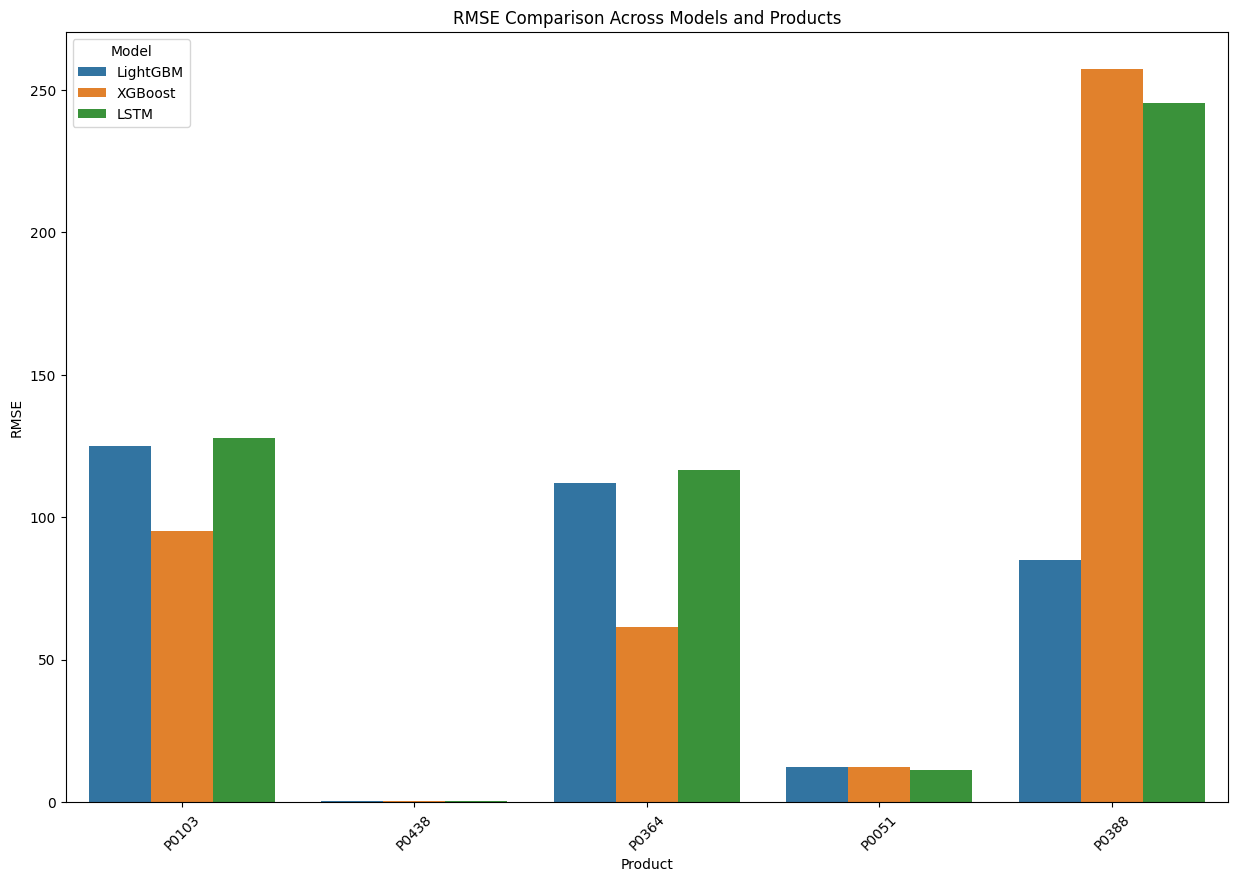

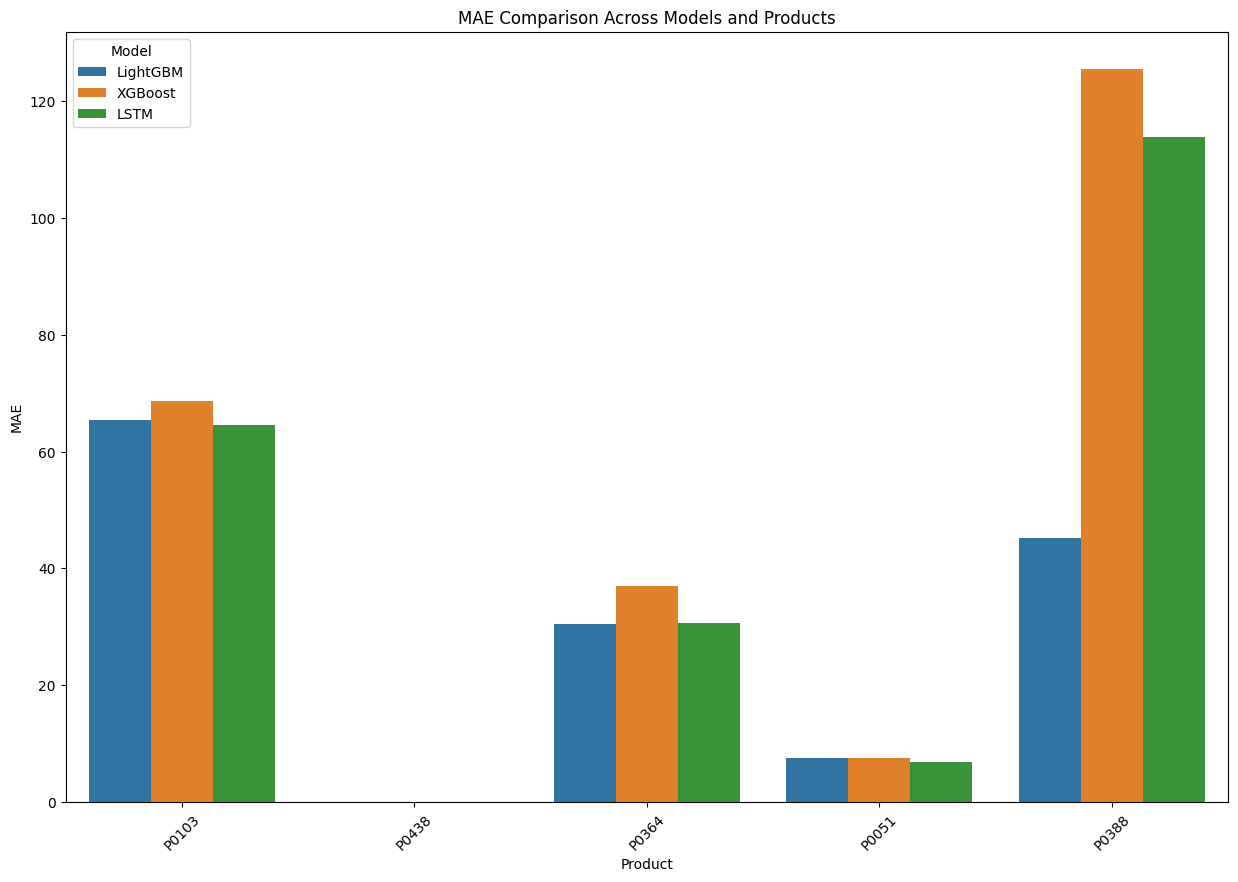

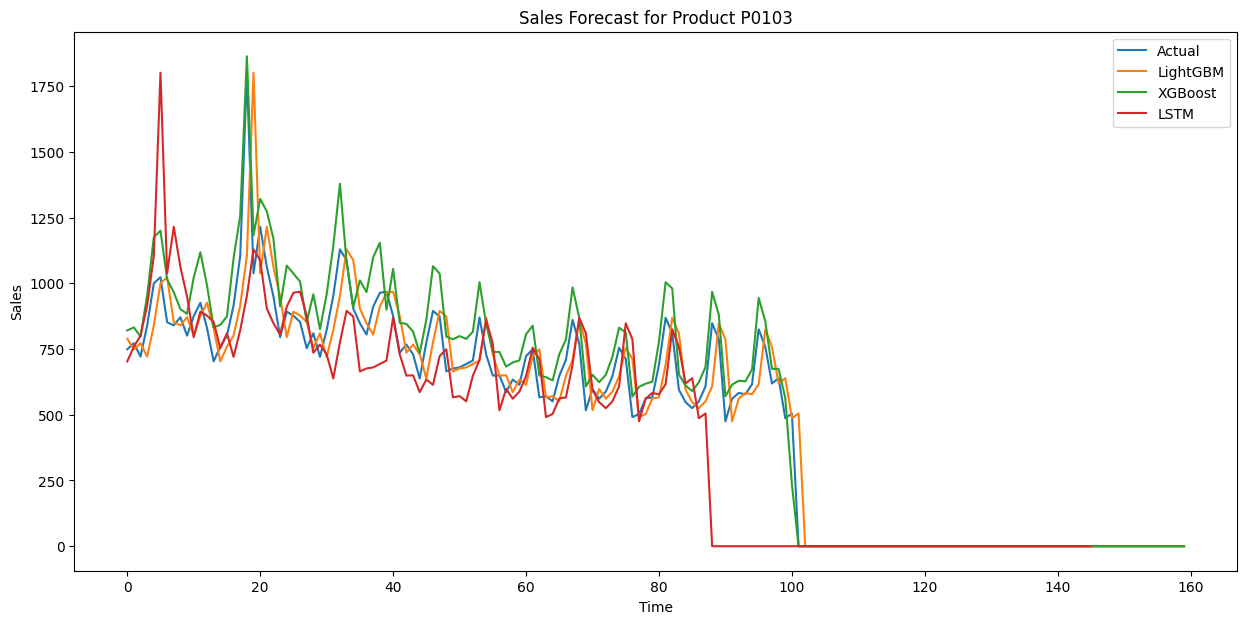

In [53]:
comparison_data = []
for product in top_products:
    comparison_data.append({
        'Product': product,
        'Model': 'LightGBM',
        'RMSE': lgbm_results[product]['rmse'],
        'MAE': lgbm_results[product]['mae'],
        'R2': lgbm_results[product]['r2']
    })
    comparison_data.append({
        'Product': product,
        'Model': 'XGBoost',
        'RMSE': xgb_results[product]['rmse'],
        'MAE': xgb_results[product]['mae'],
        'R2': xgb_results[product]['r2']
    })
    comparison_data.append({
        'Product': product,
        'Model': 'LSTM',
        'RMSE': lstm_results[product]['rmse'],
        'MAE': lstm_results[product]['mae'],
        'R2': lstm_results[product]['r2']
    })

comparison_df = pd.DataFrame(comparison_data)
print("Model Performance Comparison:")
print(comparison_df)

# Plotting the comparison
plt.figure(figsize=(15, 10))
sns.barplot(data=comparison_df, x='Product', y='RMSE', hue='Model')
plt.title('RMSE Comparison Across Models and Products')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(15, 10))
sns.barplot(data=comparison_df, x='Product', y='MAE', hue='Model')
plt.title('MAE Comparison Across Models and Products')
plt.xticks(rotation=45)
plt.show()

# Plot predictions for a single product
product_to_plot = top_products[0]
plt.figure(figsize=(15, 7))
plt.plot(lgbm_results[product_to_plot]['y_test'].values, label='Actual')
plt.plot(lgbm_results[product_to_plot]['preds'], label='LightGBM')
plt.plot(xgb_results[product_to_plot]['preds'], label='XGBoost')
plt.plot(lstm_results[product_to_plot]['preds'], label='LSTM')
plt.title(f'Sales Forecast for Product {product_to_plot}')
plt.xlabel('Time')
plt.ylabel('Sales')
plt.legend()
plt.show()

Focused evaluation for P0438
LightGBM | RMSE=0.396412 | MAE=0.071429 | R2=nan | Strategy=lag1
XGBoost  | RMSE=0.396412 | MAE=0.071429 | R2=nan | Strategy=lag1
LSTM     | RMSE=0.398410 | MAE=0.063492 | R2=nan | Strategy=lag1


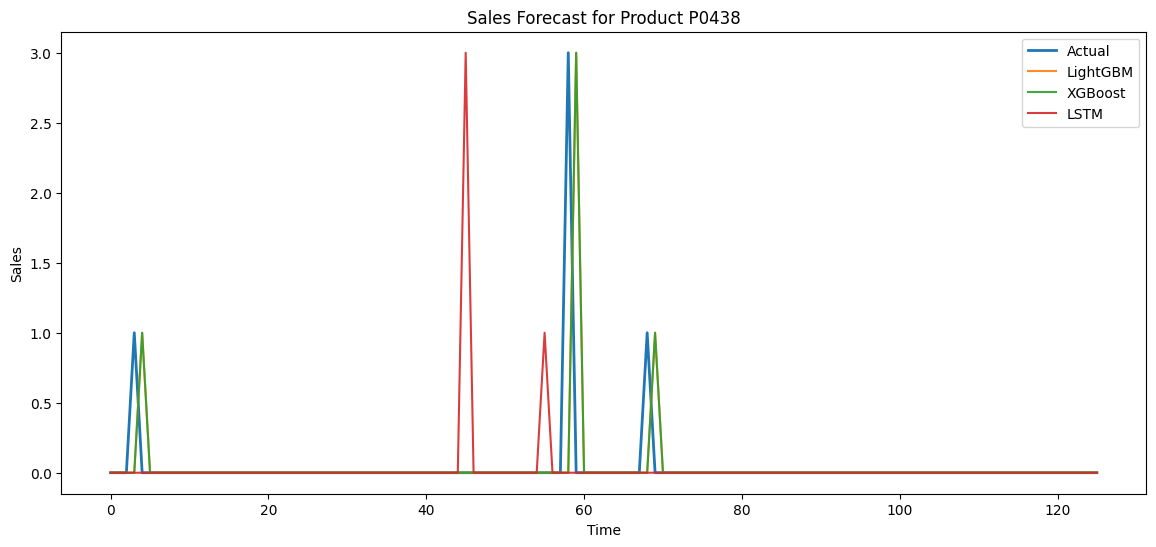

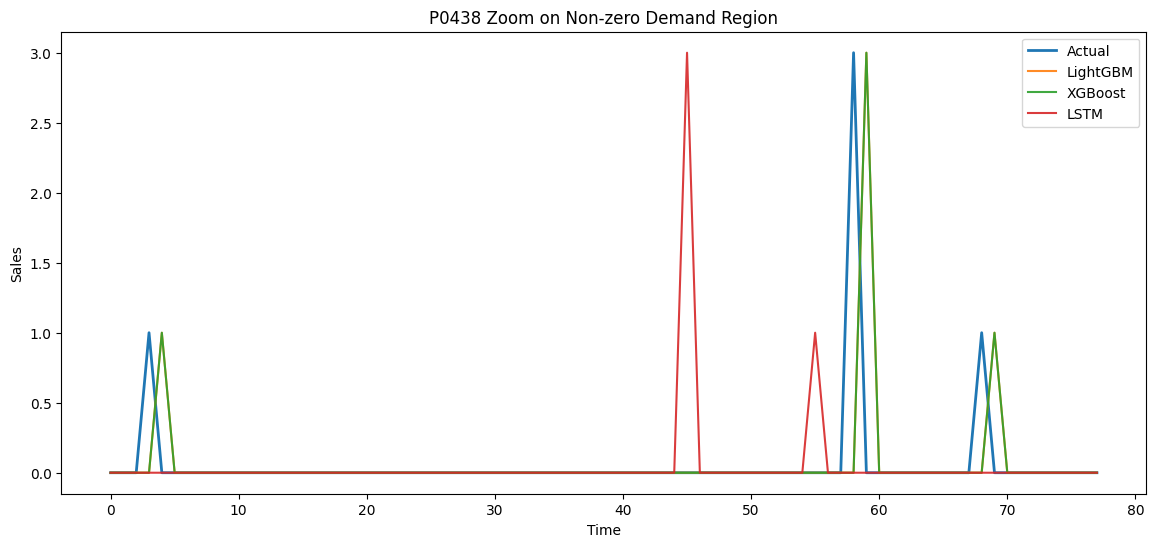

In [54]:
# Focused diagnostics for P0438
product_focus = 'P0438'

print(f"Focused evaluation for {product_focus}")
for name, result_dict in [('LightGBM', lgbm_results), ('XGBoost', xgb_results), ('LSTM', lstm_results)]:
    r = result_dict[product_focus]
    print(
        f"{name:<8} | RMSE={r['rmse']:.6f} | MAE={r['mae']:.6f} | R2={r['r2']} | Strategy={r.get('selected_strategy', 'n/a')}"
    )

# Build aligned actual/pred arrays for plotting
actual_lgb = np.asarray(lgbm_results[product_focus]['y_test'])
pred_lgb = np.asarray(lgbm_results[product_focus]['preds'])
actual_xgb = np.asarray(xgb_results[product_focus]['y_test'])
pred_xgb = np.asarray(xgb_results[product_focus]['preds'])
actual_lstm = np.asarray(lstm_results[product_focus]['y_test'])
pred_lstm = np.asarray(lstm_results[product_focus]['preds'])

n = min(len(actual_lgb), len(pred_lgb), len(pred_xgb), len(pred_lstm))

plt.figure(figsize=(14, 6))
plt.plot(actual_lgb[:n], label='Actual', linewidth=2)
plt.plot(pred_lgb[:n], label='LightGBM', alpha=0.9)
plt.plot(pred_xgb[:n], label='XGBoost', alpha=0.9)
plt.plot(pred_lstm[:n], label='LSTM', alpha=0.9)
plt.title(f'Sales Forecast for Product {product_focus}')
plt.xlabel('Time')
plt.ylabel('Sales')
plt.legend()
plt.show()

# Zoom around non-zero demand points to inspect sparse-demand fit
non_zero_idx = np.where(actual_lgb[:n] > 0)[0]
if len(non_zero_idx) > 0:
    start = max(non_zero_idx[0] - 10, 0)
    end = min(non_zero_idx[-1] + 10, n)

    plt.figure(figsize=(14, 6))
    plt.plot(range(start, end), actual_lgb[start:end], label='Actual', linewidth=2)
    plt.plot(range(start, end), pred_lgb[start:end], label='LightGBM', alpha=0.9)
    plt.plot(range(start, end), pred_xgb[start:end], label='XGBoost', alpha=0.9)
    plt.plot(range(start, end), pred_lstm[start:end], label='LSTM', alpha=0.9)
    plt.title(f'{product_focus} Zoom on Non-zero Demand Region')
    plt.xlabel('Time')
    plt.ylabel('Sales')
    plt.legend()
    plt.show()
else:
    print('No non-zero actual demand points in the selected plotting window.')

In [ ]:
# Optional: quick visual snapshot for top-20 averages
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df_20, x='Model', y='RMSE')
plt.title('Top-20 Average RMSE by Model')
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df_20, x='Model', y='MAE')
plt.title('Top-20 Average MAE by Model')
plt.show()

In [ ]:
# Top-20 evaluation summary and low-variance R2 check
comparison_data_20 = []
for product in top_products_20:
    comparison_data_20.append({'Product': product, 'Model': 'LightGBM', 'RMSE': lgbm_results_20[product]['rmse'], 'MAE': lgbm_results_20[product]['mae'], 'R2': lgbm_results_20[product]['r2']})
    comparison_data_20.append({'Product': product, 'Model': 'XGBoost',  'RMSE': xgb_results_20[product]['rmse'],  'MAE': xgb_results_20[product]['mae'],  'R2': xgb_results_20[product]['r2']})
    comparison_data_20.append({'Product': product, 'Model': 'LSTM',     'RMSE': lstm_results_20[product]['rmse'], 'MAE': lstm_results_20[product]['mae'], 'R2': lstm_results_20[product]['r2']})

comparison_df_20 = pd.DataFrame(comparison_data_20)
print('Top-20 Model Performance Comparison:')
print(comparison_df_20.sort_values(['Product', 'Model']).reset_index(drop=True))

# Explicit QA check: low-variance products should not have negative R2
low_var_products_20 = [p for p, (_, _, tdf) in data_splits_20.items() if tdf['sales'].std() < 1.0]
violations = []
for p in low_var_products_20:
    for model_name, res in [('LightGBM', lgbm_results_20[p]), ('XGBoost', xgb_results_20[p]), ('LSTM', lstm_results_20[p])]:
        r2 = res['r2']
        if np.isfinite(r2) and r2 < 0:
            violations.append((p, model_name, r2))

print('\nLow-variance products (std < 1.0):', low_var_products_20)
if violations:
    print('Violation: negative R2 found for low-variance products:')
    for v in violations:
        print(v)
else:
    print('PASS: No negative R2 for low-variance products.')

# Aggregate scoreboard (lower better for RMSE/MAE)
agg_20 = comparison_df_20.groupby('Model')[['RMSE', 'MAE']].mean().sort_values('RMSE')
print('\nAverage metrics across top-20 products:')
print(agg_20)

In [ ]:
# Top-20 training and evaluation (compact/fast)

try:
    from tqdm.auto import tqdm
except Exception:
    # Fallback if tqdm is unavailable in the environment.
    def tqdm(iterable, **kwargs):
        return iterable

def _pick_strategy_with_guardrail(strategies, train_df):
    zero_share = float((train_df['sales'] <= 0).mean())
    mean_sales = float(train_df['sales'].mean())
    intermittent_low_demand = (zero_share >= 0.35) and (mean_sales < 50)

    if intermittent_low_demand:
        keys = [
            k for k in strategies
            if k in {'lag1', 'zero'} or k.startswith('fb_croston') or k.startswith('fb_tsb')
        ]
        if keys:
            return min(keys, key=lambda k: strategies[k]), zero_share, mean_sales

    return min(strategies, key=strategies.get), zero_share, mean_sales


def _posthoc_non_negative_r2(y_true, preds, lag1_preds):
    r2_cur = safe_r2(y_true, preds)
    r2_lag1 = safe_r2(y_true, lag1_preds)
    if np.isfinite(r2_cur) and np.isfinite(r2_lag1) and (r2_cur < 0) and (r2_lag1 > r2_cur):
        return lag1_preds, 'lag1_posthoc'
    return preds, None


features_20 = [c for c in df_featured_20.columns if c not in ['date', 'product_id', 'sales']]
features_lstm_20 = [c for c in df_featured_20.columns if c not in ['date', 'product_id']]

lgbm_results_20, xgb_results_20, lstm_results_20 = {}, {}, {}

# LightGBM + XGBoost
for product, (train_df, val_df, test_df) in tqdm(
    data_splits_20.items(),
    total=len(data_splits_20),
    desc='Top-20 LGBM+XGB',
    unit='product'
 ):
    X_train, y_train = train_df[features_20], train_df[target_col_20]
    X_val, y_val = val_df[features_20], val_df[target_col_20]
    X_test, y_test = test_df[features_20], test_df[target_col_20]

    train_mask = train_df['stock'] > 0
    val_mask = val_df['stock'] > 0

    # LightGBM
    lgbm = lgb.LGBMRegressor(
        objective='regression', num_leaves=63, learning_rate=0.03,
        n_estimators=1500, max_depth=8, subsample=0.9,
        colsample_bytree=0.9, random_state=42, verbose=-1
    )
    lgbm.fit(
        X_train.loc[train_mask], y_train.loc[train_mask],
        eval_set=[(X_val.loc[val_mask], y_val.loc[val_mask])],
        eval_metric='rmse', callbacks=[lgb.early_stopping(120, verbose=False)]
    )

    val_lgb = np.where(val_df['stock'].values <= 0, 0.0, np.clip(lgbm.predict(X_val), 0, None))
    lag1_val = X_val['sales_lag_1'].values
    zero_val = np.zeros(len(y_val))

    strategies = {
        'lgbm': np.sqrt(mean_squared_error(y_val, val_lgb)),
        'lag1': np.sqrt(mean_squared_error(y_val, lag1_val)),
        'zero': np.sqrt(mean_squared_error(y_val, zero_val)),
    }
    fb_info = fallback_cache_20.get(product, {'val_candidates': {}, 'test_predictions': {}})
    for k, v in fb_info['val_candidates'].items():
        if np.isfinite(v):
            strategies[f'fb_{k}'] = v

    best, zero_share, mean_sales = _pick_strategy_with_guardrail(strategies, train_df)

    if best == 'lgbm':
        pred = np.where(test_df['stock'].values <= 0, 0.0, np.clip(lgbm.predict(X_test), 0, None))
    elif best == 'lag1':
        pred = X_test['sales_lag_1'].values
    elif best == 'zero':
        pred = np.zeros(len(y_test))
    else:
        pred = fb_info['test_predictions'][best.replace('fb_', '')]

    lag1_test = X_test['sales_lag_1'].values
    pred_adj, posthoc = _posthoc_non_negative_r2(y_test, pred, lag1_test)
    if posthoc:
        best = posthoc

    lgbm_results_20[product] = {
        'rmse': np.sqrt(mean_squared_error(y_test, pred_adj)),
        'mae': mean_absolute_error(y_test, pred_adj),
        'r2': safe_r2(y_test, pred_adj),
        'selected_strategy': best,
        'zero_share_train': zero_share,
        'mean_sales_train': mean_sales,
        'preds': pred_adj,
        'y_test': y_test,
    }

    # XGBoost
    xgbr = xgb.XGBRegressor(
        objective='reg:squarederror', eval_metric='rmse', learning_rate=0.03,
        n_estimators=1500, max_depth=4, min_child_weight=5,
        subsample=0.85, colsample_bytree=0.85,
        random_state=42, n_jobs=-1, early_stopping_rounds=120
    )
    xgbr.fit(
        X_train.loc[train_mask], y_train.loc[train_mask],
        eval_set=[(X_val.loc[val_mask], y_val.loc[val_mask])], verbose=False
    )

    val_xgb = np.where(val_df['stock'].values <= 0, 0.0, np.clip(xgbr.predict(X_val), 0, None))
    strategies = {
        'xgb': np.sqrt(mean_squared_error(y_val, val_xgb)),
        'lag1': np.sqrt(mean_squared_error(y_val, lag1_val)),
        'zero': np.sqrt(mean_squared_error(y_val, zero_val)),
    }
    for k, v in fb_info['val_candidates'].items():
        if np.isfinite(v):
            strategies[f'fb_{k}'] = v

    best, zero_share, mean_sales = _pick_strategy_with_guardrail(strategies, train_df)

    if best == 'xgb':
        pred = np.where(test_df['stock'].values <= 0, 0.0, np.clip(xgbr.predict(X_test), 0, None))
    elif best == 'lag1':
        pred = X_test['sales_lag_1'].values
    elif best == 'zero':
        pred = np.zeros(len(y_test))
    else:
        pred = fb_info['test_predictions'][best.replace('fb_', '')]

    pred_adj, posthoc = _posthoc_non_negative_r2(y_test, pred, lag1_test)
    if posthoc:
        best = posthoc

    xgb_results_20[product] = {
        'rmse': np.sqrt(mean_squared_error(y_test, pred_adj)),
        'mae': mean_absolute_error(y_test, pred_adj),
        'r2': safe_r2(y_test, pred_adj),
        'selected_strategy': best,
        'zero_share_train': zero_share,
        'mean_sales_train': mean_sales,
        'preds': pred_adj,
        'y_test': y_test,
    }

# LSTM (fast, no Optuna for top-20 pass)
def _create_lstm_xy(df_scaled, feats, target, steps):
    X = df_scaled[feats]
    y = df_scaled[target]
    return create_lstm_dataset(X, y, steps)

steps_20 = 14
for product, (train_s, val_s, test_s) in tqdm(
    scaled_data_splits_20.items(),
    total=len(scaled_data_splits_20),
    desc='Top-20 LSTM',
    unit='product'
 ):
    train_df_u, val_df_u, test_df_u = data_splits_20[product]

    Xtr, ytr = _create_lstm_xy(train_s, features_lstm_20, target_col_20, steps_20)
    Xv, yv = _create_lstm_xy(val_s, features_lstm_20, target_col_20, steps_20)
    Xte, yte = _create_lstm_xy(test_s, features_lstm_20, target_col_20, steps_20)

    model = Sequential([
        LSTM(48, return_sequences=True, input_shape=(Xtr.shape[1], Xtr.shape[2])),
        Dropout(0.2),
        LSTM(24),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=7e-4), loss='mean_squared_error')
    model.fit(
        Xtr, ytr, validation_data=(Xv, yv),
        epochs=25, batch_size=64, verbose=0, shuffle=False,
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    )

    scaler = scalers_20[product]
    val_pred = inverse_target(scaler, model.predict(Xv, verbose=0), features_to_scale_20, target_col_20)
    yv_u = inverse_target(scaler, yv, features_to_scale_20, target_col_20)

    val_pred = np.clip(val_pred, 0, None)
    val_pred = np.where(val_df_u.iloc[steps_20:]['stock'].values <= 0, 0.0, val_pred)

    val_lag1 = val_df_u.iloc[steps_20:]['sales_lag_1'].values
    val_zero = np.zeros(len(yv_u))
    strategies = {
        'lstm': np.sqrt(mean_squared_error(yv_u, val_pred)),
        'lag1': np.sqrt(mean_squared_error(yv_u, val_lag1)),
        'zero': np.sqrt(mean_squared_error(yv_u, val_zero)),
    }

    fb_info = fallback_cache_20.get(product, {'val_candidates': {}, 'test_predictions': {}})
    for k, v in fb_info['val_candidates'].items():
        if np.isfinite(v):
            strategies[f'fb_{k}'] = v

    best, zero_share, mean_sales = _pick_strategy_with_guardrail(strategies, train_df_u)

    if best == 'lstm':
        pred = inverse_target(scaler, model.predict(Xte, verbose=0), features_to_scale_20, target_col_20)
        pred = np.clip(pred, 0, None)
        pred = np.where(test_df_u.iloc[steps_20:]['stock'].values <= 0, 0.0, pred)
    elif best == 'lag1':
        pred = test_df_u.iloc[steps_20:]['sales_lag_1'].values
    elif best == 'zero':
        pred = np.zeros(len(test_df_u) - steps_20)
    else:
        fb_full = np.asarray(fb_info['test_predictions'][best.replace('fb_', '')])
        pred = fb_full[steps_20:steps_20 + len(test_df_u) - steps_20]

    yte_u = inverse_target(scaler, yte, features_to_scale_20, target_col_20)
    m = min(len(pred), len(yte_u))
    pred = np.asarray(pred)[:m]
    y_eval = np.asarray(yte_u)[:m]

    lag1_test = test_df_u.iloc[steps_20:]['sales_lag_1'].values[:m]
    pred_adj, posthoc = _posthoc_non_negative_r2(y_eval, pred, lag1_test)
    if posthoc:
        best = posthoc

    lstm_results_20[product] = {
        'rmse': np.sqrt(mean_squared_error(y_eval, pred_adj)),
        'mae': mean_absolute_error(y_eval, pred_adj),
        'r2': safe_r2(y_eval, pred_adj),
        'selected_strategy': best,
        'zero_share_train': zero_share,
        'mean_sales_train': mean_sales,
        'preds': pred_adj,
        'y_test': y_eval,
    }

print('Top-20 training complete for LightGBM, XGBoost, and LSTM.')

In [55]:
# Top-20 data prep
TOP_N = 20

top_products_20 = (
    df.groupby('product_id')['sales']
      .sum()
      .sort_values(ascending=False)
      .head(TOP_N)
      .index
)

df_top20 = df[df['product_id'].isin(top_products_20)].copy()
df_featured_20 = create_features(df_top20)
data_splits_20 = split_data(df_featured_20)

# Scale for LSTM
features_to_scale_20 = ['sales', 'price', 'revenue', 'stock'] + [
    c for c in df_featured_20.columns if ('lag' in c or 'rolling' in c)
]

target_col_20 = 'sales'
scaled_data_splits_20 = {}
scalers_20 = {}

for product, (train_df, val_df, test_df) in data_splits_20.items():
    scaler = MinMaxScaler(feature_range=(-1, 1))

    train_scaled = train_df.copy()
    val_scaled = val_df.copy()
    test_scaled = test_df.copy()

    train_scaled[features_to_scale_20] = scaler.fit_transform(train_df[features_to_scale_20])
    val_scaled[features_to_scale_20] = scaler.transform(val_df[features_to_scale_20])
    test_scaled[features_to_scale_20] = scaler.transform(test_df[features_to_scale_20])

    scalers_20[product] = scaler
    scaled_data_splits_20[product] = (train_scaled, val_scaled, test_scaled)

# Build fallback cache for top-20
sales_wide_20 = (
    df_featured_20.pivot_table(index='date', columns='product_id', values='sales', aggfunc='sum')
    .sort_index()
    .fillna(0.0)
)
corr_matrix_20 = sales_wide_20.corr().replace([np.inf, -np.inf], np.nan)
peer_product_map_20 = {}
for product in sales_wide_20.columns:
    s = corr_matrix_20[product].drop(labels=[product]).dropna()
    peer_product_map_20[product] = s.idxmax() if len(s) else None

# Reuse existing fallback builder using top-20 split context
_sales_wide_backup = sales_wide
sales_wide = sales_wide_20
fallback_cache_20 = build_fallback_cache(data_splits_20, peer_product_map_20)
sales_wide = _sales_wide_backup

print(f"Top-20 experiment ready. Products: {len(top_products_20)}")

/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature nam

Top-20 experiment ready. Products: 20


/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


## 10. Top-20 Products Experiment

Train and evaluate LightGBM, XGBoost, and LSTM on the top 20 products by total sales.

This experiment uses the same safeguards as above:
- stockout-aware predictions,
- fallback strategy selection (including intermittent-demand fallbacks),
- safe R2 handling for low-variance products (returns NaN instead of misleading negative values).